In [69]:
import re
import html
import emoji
import wordninja
import pandas as pd
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib

In [26]:
#pip install wordninja
#pip install emoji
#nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment140' dataset.
Path to dataset files: /kaggle/input/sentiment140


In [19]:
cols = ["target", "id", "date", "flag", "user", "text"]
df = pd.read_csv(r"/kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv",encoding="latin-1",names=cols, usecols=["target", "text"])

In [20]:
df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [21]:
# Remove missing values
df = df.dropna(subset=["text", "target"])

In [22]:
# 0 = Negative
# 4 = Positive
df["label"] = (df["target"] == 4).astype(int)


In [54]:
# ============================================================
# 2. Precompiled Regex
# ============================================================

URL = re.compile(
    r"(?:https?://|www\.)\S+",
    re.IGNORECASE
)

MENTION = re.compile(r"@\w+")

HASHTAG = re.compile(r"#(\w+)")

REPEAT = re.compile(r"(.)\1{2,}")

NONALPHA = re.compile(r"[^a-z!? ]")
MARKDOWN_LINK = re.compile(r"\[([^\]]*)\]\([^)]+\)")

CONTR = [
    (r"won't", "will not"),
    (r"can't", "can not"),
    (r"n't", " not"),
    (r"'re", " are"),
    (r"'m", " am"),
    (r"'ll", " will"),
    (r"'ve", " have"),
    (r"'d", " would"),
]

KEEP = {
    "no", "nor", "not", "never",
    "against",
    "don", "didn", "doesn", "isn",
    "wasn", "aren", "weren",
    "couldn", "wouldn", "shouldn",
    "won", "haven", "hasn"
}

STOP = set(stopwords.words("english")) - KEEP

In [56]:
def split_hashtag(match):
    """
    Convert:
        #BestMovieEver
    into:
        Best Movie Ever
    """

    hashtag = match.group(1)

    # wordninja splits concatenated English words
    words = wordninja.split(hashtag)

    return " " + " ".join(words) + " "

In [57]:
def clean_classical(t: str) -> str:

    t = MARKDOWN_LINK.sub(" ", t)

    # HTML entities
    t = html.unescape(t)

    # Lowercase
    t = t.lower()

    # Convert emojis to text
    t = emoji.demojize(
        t,
        delimiters=(" ", " ")
    )

    # Remove URLs
    t = URL.sub(" ", t)

    # Remove @mentions
    t = MENTION.sub(" ", t)

    # Split hashtags
    t = HASHTAG.sub(split_hashtag, t)

    # Expand contractions
    for pat, rep in CONTR:
        t = re.sub(pat, rep, t)

    # Reduce repeated characters
    t = REPEAT.sub(r"\1\1", t)

    # Keep only letters + ! ?
    t = NONALPHA.sub(" ", t)

    # Normalize whitespace
    t = " ".join(t.split())

    # Remove stopwords while preserving negations
    words = [
        word
        for word in t.split()
        if word not in STOP
    ]

    return " ".join(words)

In [61]:
test = """@swsaitchfsssasoot [http://twitpic.com/2y1zl](http://twitpic.com/2y1zl) - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"""

print(clean_classical(test))

aww bummer shoulda got david carr third day


In [58]:
df["clean"] = df["text"].map(clean_classical)
# Remove empty texts
df = df[df["clean"].str.len() > 0]

# Remove duplicate cleaned texts
df = df.drop_duplicates("clean")

In [62]:
print("\n========== CLEANING EXAMPLES ==========\n")

print(
    df[["text", "clean", "label"]]
    .head(20)
    .to_string(index=False)
)


========== CLEANING EXAMPLES ==========

                                                                                                                 text                                                                      clean  label
  @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D                                aww bummer shoulda got david carr third day      0
      is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah! upset not update facebook texting might cry result school today also blah!      0
                            @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds                          dived many times ball managed save rest go bounds      0
                                                                      my whole body feels itchy and like its on fire                                          

In [63]:
X_tr, X_te, y_tr, y_te = train_test_split(
    df["clean"],
    df["label"],
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)


In [64]:
pipe = Pipeline([
    ("tfidf",TfidfVectorizer(ngram_range=(1, 2),min_df=5,max_df=0.9,sublinear_tf=True,max_features=500_000)
    ),

    ("lr",LogisticRegression(C=2.0,solver="saga",max_iter=200,n_jobs=-1))
])


In [65]:
pipe.fit(X_tr, y_tr)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=500000, min_df=5,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('lr',
                 LogisticRegression(C=2.0, max_iter=200, n_jobs=-1,
                                    solver='saga'))])

In [66]:
pred = pipe.predict(X_te)

In [67]:
print("\n========== CLASSIFICATION REPORT ==========\n")
report = classification_report(y_te,pred,digits=4)
print(report)


========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

           0     0.8138    0.7975    0.8056     75338
           1     0.7982    0.8144    0.8062     74074

    accuracy                         0.8059    149412
   macro avg     0.8060    0.8060    0.8059    149412
weighted avg     0.8060    0.8059    0.8059    149412



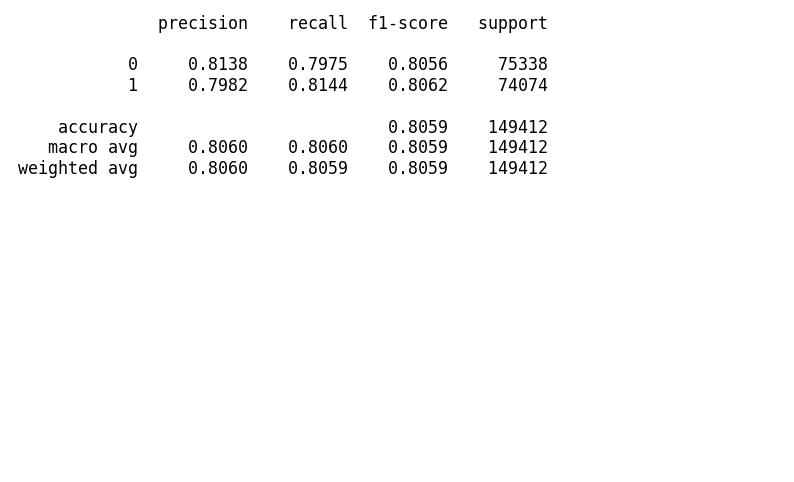

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.text(0.01, 0.99,report,fontsize=12,fontfamily="monospace",verticalalignment="top")
ax.axis("off")

# Save as image
plt.savefig(
    "classification_report.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [71]:
joblib.dump(pipe, "sentiment_model.joblib")

['sentiment_model.joblib']

-------

In [94]:
text = "I absolutely love this!!!"
text_ = "I absolutely hate this!!!"

cleaned = clean_classical(text)
cleaned_ = clean_classical(text_)

prediction = pipe.predict([cleaned])
prediction_ = pipe.predict([cleaned_])
print(f"For positive text: {prediction}",f"For Negative text: {prediction_}")

For positive text: [1] For Negative text: [0]
